Amazon Customers Sentiment Analysis

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import spacy

In [ ]:
import pandas as pd

df = pd.read_csv(
    'Amazon_Reviews.csv',
    engine='python'
)

df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [8]:
print(df.shape)
print(df.columns)

(21214, 9)
Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Reviewer Name       21214 non-null  object
 1   Profile Link        21163 non-null  object
 2   Country             21054 non-null  object
 3   Review Count        21055 non-null  object
 4   Review Date         21055 non-null  object
 5   Rating              21055 non-null  object
 6   Review Title        21055 non-null  object
 7   Review Text         21055 non-null  object
 8   Date of Experience  20947 non-null  object
dtypes: object(9)
memory usage: 1.5+ MB


In [10]:
df.isnull().sum()

,0
Reviewer Name,0
Profile Link,51
Country,160
Review Count,159
Review Date,159
Rating,159
Review Title,159
Review Text,159
Date of Experience,267


In [11]:
df.duplicated().sum()

np.int64(2)

In [12]:
df = df.drop_duplicates()

In [13]:
df = df.dropna(subset=['Review Text'])

In [14]:
df.shape

(21055, 9)

In [15]:
df.isnull().sum()

,0
Reviewer Name,0
Profile Link,0
Country,1
Review Count,0
Review Date,0
Rating,0
Review Title,0
Review Text,0
Date of Experience,108


In [16]:
df['Rating'].value_counts()

,count
Rating,
Rated 1 out of 5 stars,13123
Rated 5 out of 5 stars,4528
Rated 4 out of 5 stars,1292
Rated 2 out of 5 stars,1227
Rated 3 out of 5 stars,885


In [17]:
df['Rating_Number'] = df['Rating'].str.extract(r'(\d+)').astype(int)

In [18]:
df[['Rating', 'Rating_Number']].head(10)

,Rating,Rating_Number
0,Rated 1 out of 5 stars,1
1,Rated 1 out of 5 stars,1
2,Rated 1 out of 5 stars,1
3,Rated 1 out of 5 stars,1
4,Rated 1 out of 5 stars,1
5,Rated 1 out of 5 stars,1
6,Rated 1 out of 5 stars,1
7,Rated 5 out of 5 stars,5
8,Rated 1 out of 5 stars,1
9,Rated 5 out of 5 stars,5


In [19]:
df['Rating_Number'].value_counts().sort_index()

,count
Rating_Number,
1,13123
2,1227
3,885
4,1292
5,4528


In [20]:
df['Rating_Number'].mean()

np.float64(2.1866540014248397)

In [21]:
df['Review Date'] = pd.to_datetime(df['Review Date'], errors='coerce')

In [22]:
df['Review Date'].head()

,Review Date
0,2024-09-16 13:44:26+00:00
1,2024-09-16 18:26:46+00:00
2,2024-09-16 21:47:39+00:00
3,2024-09-17 07:15:49+00:00
4,2024-09-16 18:37:17+00:00


In [23]:
df['Review Text'].head(10)

,Review Text
0,"I registered on the website, tried to order a ..."
1,Had multiple orders one turned up and driver h...
2,I informed these reprobates that I WOULD NOT B...
3,I have bought from Amazon before and no proble...
4,If I could give a lower rate I would! I cancel...
5,Terrible you get customer service reps that ar...
6,Amazon has a way of tainting a great product d...
7,I love amazon! I use it for half my shopping. ...
8,I applied for a job with Amazon. I completed a...
9,I had a great experience with their customer s...


In [24]:
df['Cleaned_Review'] = df['Review Text'].str.lower()

In [25]:
df['Cleaned_Review'].head(10)

,Cleaned_Review
0,"i registered on the website, tried to order a ..."
1,had multiple orders one turned up and driver h...
2,i informed these reprobates that i would not b...
3,i have bought from amazon before and no proble...
4,if i could give a lower rate i would! i cancel...
5,terrible you get customer service reps that ar...
6,amazon has a way of tainting a great product d...
7,i love amazon! i use it for half my shopping. ...
8,i applied for a job with amazon. i completed a...
9,i had a great experience with their customer s...


In [26]:
df['Cleaned_Review'] = df['Cleaned_Review'].apply(
    lambda x: re.sub(r'[^\w\s]', '', x)
)

In [27]:
df['Cleaned_Review'] = df['Cleaned_Review'].str.replace(
    r'\s+', ' ', regex=True
).str.strip()

In [28]:
df[['Cleaned_Review','Review Text']].head(10)

,Cleaned_Review,Review Text
0,i registered on the website tried to order a l...,"I registered on the website, tried to order a ..."
1,had multiple orders one turned up and driver h...,Had multiple orders one turned up and driver h...
2,i informed these reprobates that i would not b...,I informed these reprobates that I WOULD NOT B...
3,i have bought from amazon before and no proble...,I have bought from Amazon before and no proble...
4,if i could give a lower rate i would i cancell...,If I could give a lower rate I would! I cancel...
5,terrible you get customer service reps that ar...,Terrible you get customer service reps that ar...
6,amazon has a way of tainting a great product d...,Amazon has a way of tainting a great product d...
7,i love amazon i use it for half my shopping th...,I love amazon! I use it for half my shopping. ...
8,i applied for a job with amazon i completed al...,I applied for a job with Amazon. I completed a...
9,i had a great experience with their customer s...,I had a great experience with their customer s...


In [29]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [30]:
from nltk.corpus import stopwords

In [31]:
stop_words = set(stopwords.words('english'))

In [32]:
stop_words = stop_words - {'not', 'no', 'never'}

In [33]:
text = df['Cleaned_Review'].iloc[0]

words = text.split()

filtered_words = [word for word in words if word not in stop_words]

print("Before:", text)
print("After:", " ".join(filtered_words))

Before: i registered on the website tried to order a laptop entered all the details but instead of charging me and sending the product they froze my account demanding various verification documents i sent them over they said they would review them within 24 hours in reality its been a week and no one can help or give any truthful estimate of when it will be resolved they just tell me to wait ive never seen such a horrible marketplace in my life i hope those who came up with this cant buy food in a store receiving a document review request that takes forever to process
After: registered website tried order laptop entered details instead charging sending product froze account demanding various verification documents sent said would review within 24 hours reality week no one help give truthful estimate resolved tell wait ive never seen horrible marketplace life hope came cant buy food store receiving document review request takes forever process


In [34]:
df['Cleaned_Review'] = df['Cleaned_Review'].apply(
    lambda text: " ".join(
        word for word in text.split()
        if word not in stop_words
    )
)

In [35]:
df[['Review Text', 'Cleaned_Review']].head(10)

,Review Text,Cleaned_Review
0,"I registered on the website, tried to order a ...",registered website tried order laptop entered ...
1,Had multiple orders one turned up and driver h...,multiple orders one turned driver phone no doo...
2,I informed these reprobates that I WOULD NOT B...,informed reprobates would not going visit sick...
3,I have bought from Amazon before and no proble...,bought amazon no problems happy service price ...
4,If I could give a lower rate I would! I cancel...,could give lower rate would cancelled amazon p...
5,Terrible you get customer service reps that ar...,terrible get customer service reps clearly hom...
6,Amazon has a way of tainting a great product d...,amazon way tainting great product due inabilit...
7,I love amazon! I use it for half my shopping. ...,love amazon use half shopping prime membership...
8,I applied for a job with Amazon. I completed a...,applied job amazon completed steps including s...
9,I had a great experience with their customer s...,great experience customer service delivered or...


In [36]:
nlp = spacy.load('en_core_web_sm')

In [37]:
def lemmatize_text(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])

df['Cleaned_Review'] = df['Cleaned_Review'].apply(lemmatize_text)

In [38]:
df[['Review Text', 'Cleaned_Review']].head(10)

,Review Text,Cleaned_Review
0,"I registered on the website, tried to order a ...",register website try order laptop enter detail...
1,Had multiple orders one turned up and driver h...,multiple order one turn driver phone no door n...
2,I informed these reprobates that I WOULD NOT B...,inform reprobate would not go visit sick relat...
3,I have bought from Amazon before and no proble...,buy amazon no problem happy service price amaz...
4,If I could give a lower rate I would! I cancel...,could give low rate would cancel amazon prime ...
5,Terrible you get customer service reps that ar...,terrible get customer service rep clearly home...
6,Amazon has a way of tainting a great product d...,amazon way taint great product due inability s...
7,I love amazon! I use it for half my shopping. ...,love amazon use half shop prime membership wor...
8,I applied for a job with Amazon. I completed a...,applied job amazon complete step include send ...
9,I had a great experience with their customer s...,great experience customer service deliver orde...


In [39]:
def get_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

In [40]:
df['Sentiment'] = df['Rating_Number'].apply(get_sentiment)

In [41]:
df[['Rating_Number', 'Sentiment']].head(10)

,Rating_Number,Sentiment
0,1,Negative
1,1,Negative
2,1,Negative
3,1,Negative
4,1,Negative
5,1,Negative
6,1,Negative
7,5,Positive
8,1,Negative
9,5,Positive


**Sentiment Count**

In [42]:
df['Sentiment'].value_counts()

,count
Sentiment,
Negative,14350
Positive,5820
Neutral,885


In [43]:
sentiment_percentage = df['Sentiment'].value_counts(normalize=True) * 100

print(sentiment_percentage)

Sentiment
Negative    68.154833
Positive    27.641890
Neutral      4.203277
Name: proportion, dtype: float64


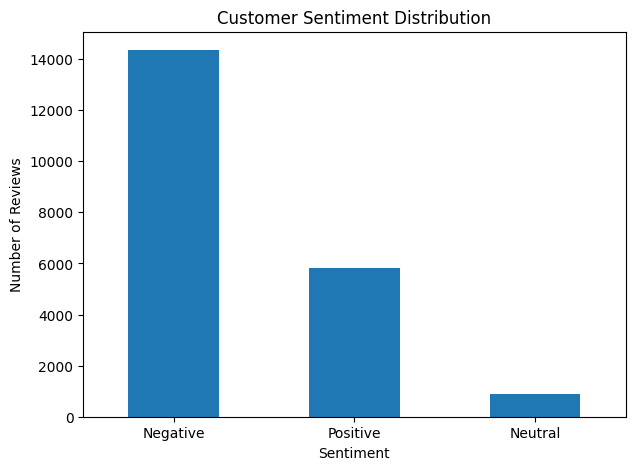

In [44]:
import matplotlib.pyplot as plt

sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind='bar')

plt.title('Customer Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)

plt.show()

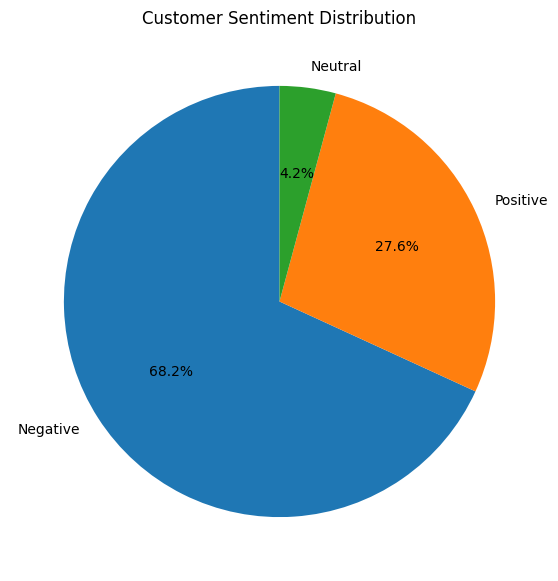

In [45]:
plt.figure(figsize=(7, 7))

sentiment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90

)

plt.title('Customer Sentiment Distribution')
plt.ylabel('')

plt.show()

In [46]:
negative_reviews = df[df['Sentiment'] == 'Negative']

In [47]:
negative_text = ' '.join(negative_reviews['Cleaned_Review'])

In [48]:
positive_reviews = df[df['Sentiment'] == 'Positive']

positive_text = ' '.join(positive_reviews['Cleaned_Review'])

In [49]:
from collections import Counter

negative_words = negative_text.split()

negative_word_counts = Counter(negative_words)

negative_word_counts.most_common(20)

[('not', 29364),
 ('amazon', 24735),
 ('customer', 10575),
 ('get', 10155),
 ('order', 10134),
 ('service', 9165),
 ('item', 8240),
 ('do', 7865),
 ('no', 7182),
 ('delivery', 6835),
 ('day', 6718),
 ('time', 6669),
 ('say', 6482),
 ('refund', 5200),
 ('account', 5147),
 ('deliver', 4958),
 ('tell', 4822),
 ('would', 4747),
 ('go', 4745),
 ('use', 4653)]

In [50]:
positive_words = positive_text.split()

positive_word_counts = Counter(positive_words)

positive_word_counts.most_common(20)

[('amazon', 4766),
 ('not', 2733),
 ('service', 2029),
 ('good', 1830),
 ('customer', 1528),
 ('always', 1455),
 ('order', 1435),
 ('great', 1327),
 ('time', 1268),
 ('delivery', 1237),
 ('get', 1200),
 ('item', 1166),
 ('product', 1117),
 ('find', 1039),
 ('I', 980),
 ('prime', 978),
 ('use', 957),
 ('buy', 920),
 ('price', 878),
 ('review', 838)]

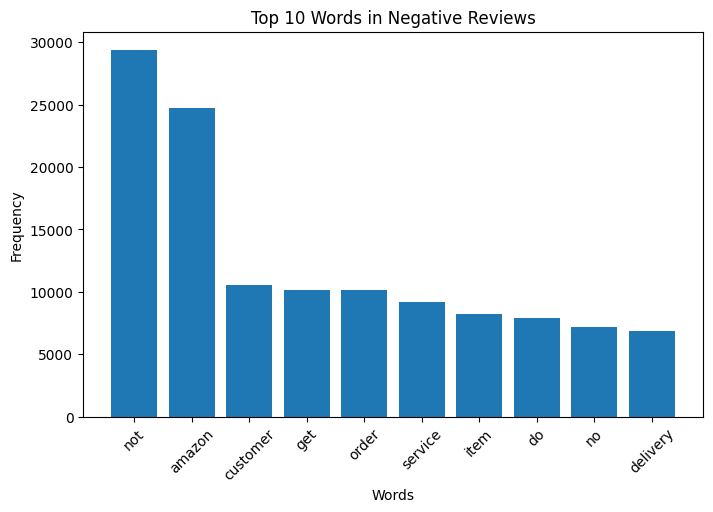

In [51]:
top_negative = dict(negative_word_counts.most_common(10))

plt.figure(figsize=(8, 5))
plt.bar(top_negative.keys(), top_negative.values())

plt.title('Top 10 Words in Negative Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.show()

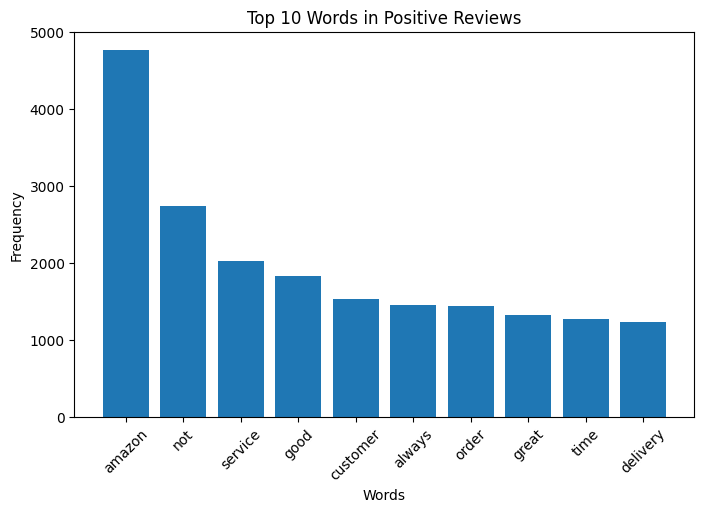

In [52]:
top_positive = dict(positive_word_counts.most_common(10))

plt.figure(figsize=(8, 5))
plt.bar(top_positive.keys(), top_positive.values())

plt.title('Top 10 Words in Positive Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.show()

In [53]:
df['Month'] = df['Review Date'].dt.to_period('M')

/tmp/ipykernel_2435/3164754886.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['Month'] = df['Review Date'].dt.to_period('M')


In [54]:
df[['Review Date', 'Month']].head()

,Review Date,Month
0,2024-09-16 13:44:26+00:00,2024-09
1,2024-09-16 18:26:46+00:00,2024-09
2,2024-09-16 21:47:39+00:00,2024-09
3,2024-09-17 07:15:49+00:00,2024-09
4,2024-09-16 18:37:17+00:00,2024-09


In [55]:
monthly_sentiment = df.groupby(
    ['Month', 'Sentiment']
).size().unstack(fill_value=0)

In [56]:
print(monthly_sentiment)

Sentiment  Negative  Neutral  Positive
Month                                 
2007-08           0        0         1
2008-04           0        0         1
2008-09           0        1         0
2008-12           0        0         1
2009-03           0        0         1
...             ...      ...       ...
2024-05         257       16        34
2024-06         299       10        40
2024-07         342       11        46
2024-08         318       13        44
2024-09         198       10        34

[184 rows x 3 columns]


<Figure size 1000x600 with 0 Axes>

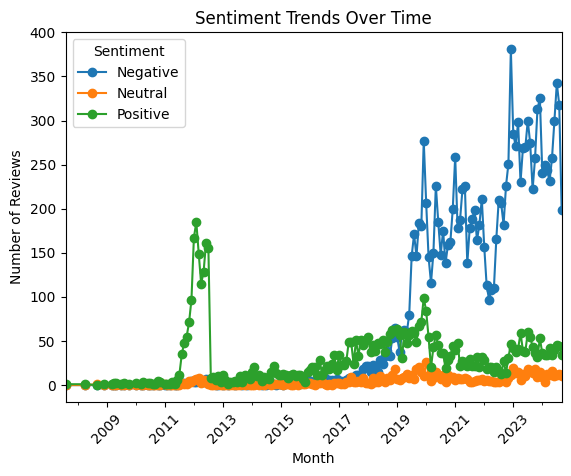

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

monthly_sentiment.plot(kind='line', marker='o')

plt.title('Sentiment Trends Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)

plt.show()

In [58]:
pd.crosstab(df['Rating_Number'], df['Sentiment'])

Sentiment,Negative,Neutral,Positive
Rating_Number,,,
1,13123,0,0
2,1227,0,0
3,0,885,0
4,0,0,1292
5,0,0,4528


In [59]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [60]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [62]:
text = df['Cleaned_Review'].iloc[0]
print(text)
score = sia.polarity_scores(text)

print(score)

register website try order laptop enter detail instead charge send product freeze account demand various verification document send say would review within 24 hour reality week no one help give truthful estimate resolve tell wait I ve never see horrible marketplace life hope come can not buy food store receive document review request take forever process
{'neg': 0.056, 'neu': 0.713, 'pos': 0.231, 'compound': 0.8898}


In [63]:
def classify_sentiment(text):
    score = sia.polarity_scores(text)['compound']

    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

In [64]:
df['Text_Sentiment'] = df['Cleaned_Review'].apply(classify_sentiment)

In [65]:
df[['Review Text', 'Rating_Number', 'Text_Sentiment']].head(10)

,Review Text,Rating_Number,Text_Sentiment
0,"I registered on the website, tried to order a ...",1,Positive
1,Had multiple orders one turned up and driver h...,1,Negative
2,I informed these reprobates that I WOULD NOT B...,1,Positive
3,I have bought from Amazon before and no proble...,1,Negative
4,If I could give a lower rate I would! I cancel...,1,Negative
5,Terrible you get customer service reps that ar...,1,Positive
6,Amazon has a way of tainting a great product d...,1,Positive
7,I love amazon! I use it for half my shopping. ...,5,Positive
8,I applied for a job with Amazon. I completed a...,1,Negative
9,I had a great experience with their customer s...,5,Positive


In [66]:
df['Text_Sentiment'].value_counts()

,count
Text_Sentiment,
Positive,10639
Negative,8844
Neutral,1572


In [67]:
df['Text_Sentiment'].value_counts(normalize=True) * 100

,proportion
Text_Sentiment,
Positive,50.529565
Negative,42.004275
Neutral,7.466160


In [68]:
pd.crosstab(df['Rating_Number'], df['Text_Sentiment'])

Text_Sentiment,Negative,Neutral,Positive
Rating_Number,,,
1,7607,713,4803
2,542,86,599
3,262,109,514
4,141,155,996
5,292,509,3727


In [72]:
pd.crosstab(
    df['Rating_Number'],
    df['Text_Sentiment'],
    normalize='index'
) * 100

Text_Sentiment,Negative,Neutral,Positive
Rating_Number,,,
1,57.966928,5.433209,36.599863
2,44.172779,7.008965,48.818256
3,29.604520,12.316384,58.079096
4,10.913313,11.996904,77.089783
5,6.448763,11.241166,82.310071


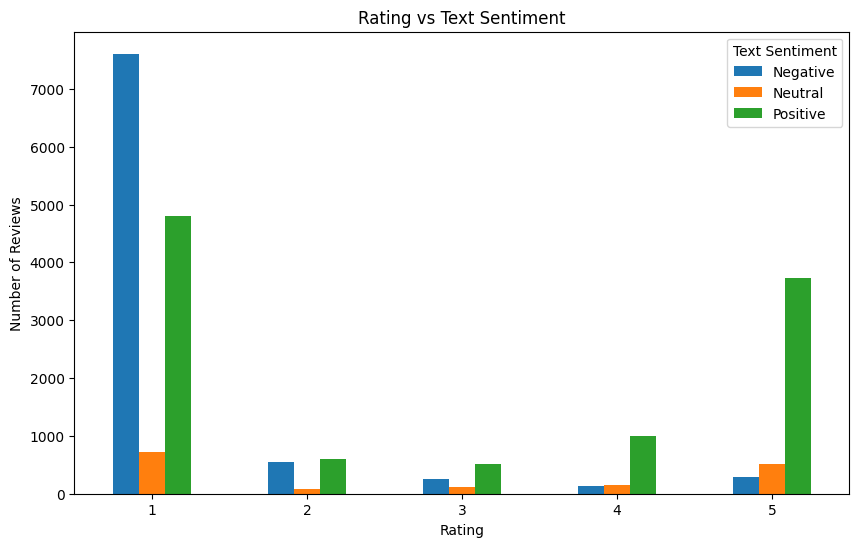

In [70]:
rating_sentiment = pd.crosstab(
    df['Rating_Number'],
    df['Text_Sentiment']
)

rating_sentiment.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Rating vs Text Sentiment')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Text Sentiment')

plt.show()

In [ ]:
df.to_csv('Amazon_Reviews_Final.csv', index=False)

# **`Key Insights`**




1. Overall Sentiment:The text-based sentiment analysis shows that 50.53% of the reviews are positive, 42.00% are negative, and 7.47% are neutral. Although positive reviews represent the largest category, the high percentage of negative reviews indicates significant customer dissatisfaction.
2.  Customer Satisfaction:
The average customer rating is approximately 2.19 out of 5, indicating a relatively low overall rating level in the dataset.

3.  Negative Feedback Patterns:Negative reviews frequently mention terms such as customer, service, order, delivery, refund, and account. This suggests that customer service, delivery, refunds, and account-related issues are major areas of customer concern

4.  Positive Feedback Patterns:Positive reviews commonly contain words such as good, great, service, order, delivery, product, Prime, and price. This indicates that customers appreciate product availability, service quality, delivery, Prime benefits, and pricing.

5.  Relationship Between Ratings and Text Sentiment:
Higher ratings generally have a higher proportion of positive text sentiment. For example, 82.31% of 5-star reviews were classified as positive, compared with 36.60% of 1-star reviews.
6.   Mixed Feedback:
The results also show that ratings and text sentiment do not always agree. For example, 36.60% of 1-star reviews were classified as positive by the text-based sentiment analyzer. This may indicate mixed feedback, contextual language, or limitations of automated sentiment analysis.








# **Recommendations for Product Improvement and Customer Satisfaction**



1.   Improve Delivery Performance:
Reduce delivery delays and improve the accuracy of estimated delivery times. Better tracking and communication can help reduce customer frustration.
2.   Enhance Customer Service:
Improve response times and provide faster and more effective solutions to customer problems. Clear communication can significantly improve customer satisfaction.


3.   Simplify the Refund Process:
Make refund procedures easier to understand and provide customers with clear information about refund status and processing times.
4.   Improve Account Support:
Make account verification and account-related procedures clearer and provide faster assistance when customers face account problems.

5.   Maintain Existing Strengths:
Positive reviews show appreciation for products, delivery, service, Prime benefits, and pricing. These areas should be maintained and continuously improved.
6.   Monitor Negative Feedback Regularly:
Regular analysis of customer reviews can help identify new problems early and allow the company to take corrective action before they become widespread.

7. Use Customer Feedback for Continuous Improvement:
Customer reviews should be analyzed regularly to identify recurring complaints and positive experiences. This can support better service quality, customer retention, and overall satisfaction.









# **Conclusion**

The Amazon customer review analysis revealed that customer feedback contains both positive and negative experiences. The text-based sentiment analysis classified 50.53% of reviews as positive, 42.00% as negative, and 7.47% as neutral. The analysis also identified customer service, delivery, orders, refunds, and account-related issues as important areas of negative feedback.


Overall, the findings suggest that improving delivery reliability, customer support, refund processing, and account services could help increase customer satisfaction. At the same time, the positive aspects identified in customer reviews should be maintained to improve customer experience and loyalty.